In [75]:
import pandas as pd

In [76]:
data = pd.read_csv("final_merged_data.csv")

In [77]:
data.head()

,_id,tripNumber,deviceID,routeNumber,blockNumber,tripStartTime,tripEndTime,onTimePct,latePct,lateMax,earlyPct,earlyMax,eventTime,apcBoardingCount,apcAlightingCount,doorId,busNumber,stopNumber,latitude,longitude
0,5ddc78d6586a68753e53979b,701011,04773023-00,7,702,2019-11-25 18:59:26+00:00,2019-11-25 19:40:02+00:00,0.00000,0.00000,0,0.00000,0,2019-11-25 19:31:15+00:00,1,0,1,5378,172,35.204527,-111.611127
1,5c53d7febb175febded9cfc6,1001013,05071686-01,10,702,2019-01-31 21:26:37+00:00,2019-01-31 22:00:02+00:00,0.00000,0.14286,484,0.00000,0,2019-01-31 21:53:02+00:00,1,0,1,5356,15,35.182975,-111.657018
2,5836075a2e372de087bf8513,702004,04763615-00,7,702,2016-11-23 15:40:02+00:00,2016-11-23 16:40:02+00:00,0.00000,0.00000,0,0.00000,0,2016-11-23 16:21:51+00:00,1,0,1,5375,171,35.214127,-111.613570
3,64120c821fff84bc2a1c2bfc,70101006,04772682-00,7,701,2023-03-15 15:37:34+00:00,2023-03-15 16:17:07+00:00,0.14286,0.00000,0,0.14286,18,2023-03-15 15:47:40+00:00,0,0,2,5377,24,35.193643,-111.650335
4,63766a0d532183190904b566,201403,05071649-00,2,201,2022-11-17 14:07:40+00:00,2022-11-17 15:09:57+00:00,0.00000,0.00000,0,0.00000,0,2022-11-17 15:07:05+00:00,0,2,2,5376,69,35.199788,-111.649410


In [78]:
# Descriptive Statistics
desc_stats = data.describe()

In [79]:
# Check for missing values
missing_values = data.isnull().sum()
missing_values

_id                  0
tripNumber           0
deviceID             0
routeNumber          0
blockNumber          0
tripStartTime        0
tripEndTime          0
onTimePct            0
latePct              0
lateMax              0
earlyPct             0
earlyMax             0
eventTime            0
apcBoardingCount     0
apcAlightingCount    0
doorId               0
busNumber            0
stopNumber           0
latitude             0
longitude            0
dtype: int64

In [80]:
# Display descriptive statistics and missing values
desc_stats

,tripNumber,routeNumber,blockNumber,onTimePct,latePct,lateMax,earlyPct,earlyMax,apcBoardingCount,apcAlightingCount,doorId,busNumber,stopNumber,latitude,longitude
count,1.000000e+02,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,2.558132e+06,12.990000,1142.840000,0.010048,0.040038,77.250000,0.010048,5.100000,1.110000,1.000000,1.680000,5368.570000,65.590000,35.195071,-111.639305
std,8.626800e+06,18.143366,1520.794733,0.037213,0.106234,184.957728,0.037213,25.629647,2.356573,2.112971,0.664846,9.407986,77.749156,0.017317,0.028053
min,8.800000e+01,2.000000,201.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,5356.000000,3.000000,35.160358,-111.670995
25%,3.017800e+05,3.000000,702.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,5360.000000,17.000000,35.183947,-111.658069
50%,1.001163e+06,10.000000,702.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,5367.000000,35.000000,35.193752,-111.652607
75%,1.004502e+06,10.000000,1001.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,2.000000,5377.000000,89.250000,35.208240,-111.617800
max,7.010101e+07,66.000000,6601.000000,0.166670,0.500010,1001.000000,0.166670,201.000000,11.000000,17.000000,3.000000,5386.000000,512.000000,35.235357,-111.575350


In [81]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Selecting features and target variable
X = data[['routeNumber', 'blockNumber', 'latitude', 'longitude']]  # Features
y = data['apcBoardingCount']  # Target variable

In [82]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [83]:
# Initializing the Linear Regression model
lr_model = LinearRegression()

In [84]:
# Fitting the model with the training data
lr_model.fit(X_train, y_train)

LinearRegression()

In [85]:
# Making predictions on the test set
y_pred = lr_model.predict(X_test)

In [86]:
# Evaluating the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [87]:
# Displaying evaluation metrics
mse, rmse, r2

(4.155673059262081, 2.038546800851548, -0.08220652584950039)

The MSE and RMSE values indicate the average squared difference and the standard deviation of the residuals, respectively. Given the nature of our target variable (apcBoardingCount), an RMSE of approximately 2 suggests that, on average, the model's predictions are about 2 passengers away from the actual boarding counts.

However, the negative R² value indicates that the model performs worse than a simple mean-based prediction model. This outcome suggests that the selected features may not have a strong linear relationship with the apcBoardingCount, or the relationship between the features and the target variable is more complex than a linear regression can capture.

Improving the model could involve several steps, such as:

<b>Feature Engineering:</b> Creating new features that might better capture the relationship with the target variable, such as the time of day or day of the week derived from tripStartTime. <br>
<b>Model Complexity:</b> Trying more complex models that can capture non-linear relationships, such as random forests or gradient boosting machines.<br>
<b>Data Enrichment:</b> Including additional relevant data, if available, that could impact passenger boarding counts, such as weather conditions, special events, or holidays.

In [88]:
from sklearn.ensemble import RandomForestRegressor

# Initializing the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [89]:
# Fitting the model with the training data
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [90]:
# Making predictions on the test set
y_pred_rf = rf_model.predict(X_test)

In [91]:
# Evaluating the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

In [92]:
# Displaying evaluation metrics for the Random Forest model
mse_rf, rmse_rf, r2_rf

(7.792935000000002, 2.791582884314919, -1.0294101562500009)

Interestingly, the Random Forest model performed worse than the Linear Regression model according to these metrics. The increase in MSE and RMSE indicates that the predictions are, on average, further away from the actual values. Furthermore, the negative R² value, which has decreased even more, suggests that the model does not adequately explain the variance in the boarding counts.

This outcome could be due to several factors, including the possibility that the selected features do not have a strong predictive relationship with the target variable or that the complexity added by the Random Forest model overfits to noise in the training data rather than capturing underlying patterns.

To address these challenges and improve model performance, consider:

<b>Enhanced Feature Engineering:</b> Investigate the creation of more informative features, including temporal features (time of day, day of week) or interaction terms between existing features. <br>
<b>Parameter Tuning:</b> Experiment with tuning the hyperparameters of the Random Forest model to find a more optimal configuration that might reduce overfitting.<br>
<b>Model Exploration:</b> Try other modeling techniques or machine learning algorithms that might be more suited to the characteristics of this dataset.

In [93]:
from datetime import datetime

In [94]:
# Function to extract hour of day and day of week from tripStartTime
def extract_time_features(df):
    # Convert tripStartTime to datetime
    df['tripStartTime'] = pd.to_datetime(df['tripStartTime'])
    # Extract hour of day
    df['hourOfDay'] = df['tripStartTime'].dt.hour
    # Extract day of week (0=Monday, 6=Sunday)
    df['dayOfWeek'] = df['tripStartTime'].dt.dayofweek
    return df

# Apply the function to our dataset
data_fe = extract_time_features(data.copy())


In [95]:

# Creating a feature for route popularity based on historical average boarding count per route
route_popularity = data_fe.groupby('routeNumber')['apcBoardingCount'].mean().reset_index()
route_popularity.columns = ['routeNumber', 'routeAvgBoardingCount']

In [96]:
# Merge the route popularity back into the original dataframe
data_fe = pd.merge(data_fe, route_popularity, on='routeNumber', how='left')

In [97]:

# Selecting new features including the engineered ones
X_fe = data_fe[['routeNumber', 'blockNumber', 'latitude', 'longitude', 'hourOfDay', 'dayOfWeek', 'routeAvgBoardingCount']]

In [98]:
# Splitting the dataset into training and testing sets with the new features
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_fe, y, test_size=0.2, random_state=42)

In [99]:
# Fitting the Random Forest model with the new features
rf_model_fe = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_fe.fit(X_train_fe, y_train_fe)

RandomForestRegressor(random_state=42)

In [100]:
# Making predictions on the test set with the new features
y_pred_rf_fe = rf_model_fe.predict(X_test_fe)

In [101]:
# Evaluating the model with the new features
mse_rf_fe = mean_squared_error(y_test_fe, y_pred_rf_fe)
rmse_rf_fe = np.sqrt(mse_rf_fe)
r2_rf_fe = r2_score(y_test_fe, y_pred_rf_fe)

In [102]:
# Displaying evaluation metrics for the Random Forest model with the new features
mse_rf_fe, rmse_rf_fe, r2_rf_fe

(5.1459850000000005, 2.2684763609083523, -0.34010026041666697)

The MSE and RMSE have decreased compared to the previous Random Forest model without the enhanced features, indicating an improvement in the model's prediction accuracy. However, the R² value is still negative, although it has improved, suggesting that the model's explanatory power has increased but still does not outperform a simple mean-based prediction model.

These results highlight the complexity of predicting passenger boarding counts and the potential need for further model refinement or exploration of additional features and modeling techniques.

Potential next steps could include:

<b>Hyperparameter Tuning:</b> Adjusting the Random Forest model's hyperparameters to find a more optimal configuration that might better capture the relationships in the data. <br>
<b>Model Exploration:</b> Trying other machine learning algorithms, such as Gradient Boosting Machines (GBM) or Neural Networks, which might be more adept at handling the complexities of the dataset.<br>
<b>Data Enrichment:</b> If more data is available, incorporating additional contextual features such as weather conditions, holidays, and special events might further improve predictive performance.

In [103]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Sample additional events data
events_data = pd.DataFrame({
    'date': pd.to_datetime(['2024-05-15', '2024-07-04', '2024-09-01']),  # example dates
    'event_type': ['graduation', 'holiday', 'sports_game']
})

In [104]:
# Convert 'tripStartTime' to datetime and extract the date part for merging
data['tripStartTime'] = pd.to_datetime(data['tripStartTime'])
data['date_for_merge'] = data['tripStartTime'].dt.date

# Extract hour and day of week from tripStartTime
data['hour_of_day'] = data['tripStartTime'].dt.hour
data['day_of_week'] = data['tripStartTime'].dt.dayofweek

# Convert 'date' in events_data to datetime if not already done
events_data['date'] = pd.to_datetime(events_data['date']).dt.date

In [105]:
# Merge the main DataFrame with the events data
data = pd.merge(data, events_data, left_on='date_for_merge', right_on='date', how='left')

# Drop the temporary 'date_for_merge' column
data.drop(['date_for_merge', 'date'], axis=1, inplace=True)

# Handle missing values in 'event_type'
data['event_type'].fillna('no_event', inplace=True)

In [106]:
# Encode 'event_type' as categorical variables
event_dummies = pd.get_dummies(data['event_type'], prefix='event')
data = pd.concat([data, event_dummies], axis=1)

# Now you should have the 'event_graduation', 'event_holiday', 'event_sports_game' columns in your data
# If you are not sure about the column names, you can check with data.columns

# Handling outliers for 'apcBoardingCount' using IQR
Q1 = data['apcBoardingCount'].quantile(0.25)
Q3 = data['apcBoardingCount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
data = data[(data['apcBoardingCount'] >= lower_bound) & (data['apcBoardingCount'] <= upper_bound)]

In [107]:
# Feature Selection
# Update feature list based on the actual features present after dummy encoding
feature_columns = ['routeNumber', 'blockNumber', 'latitude', 'longitude',
                   'hour_of_day', 'day_of_week']
feature_columns.extend(event_dummies.columns.tolist())  # Add the dummy variable column names

X = data[feature_columns]
y = data['apcBoardingCount']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [108]:
# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display evaluation metrics
print(f"MSE: {mse}, RMSE: {rmse}, R-squared: {r2}")

MSE: 0.8733499999999998, RMSE: 0.9345319684205564, R-squared: -0.2803864253393662


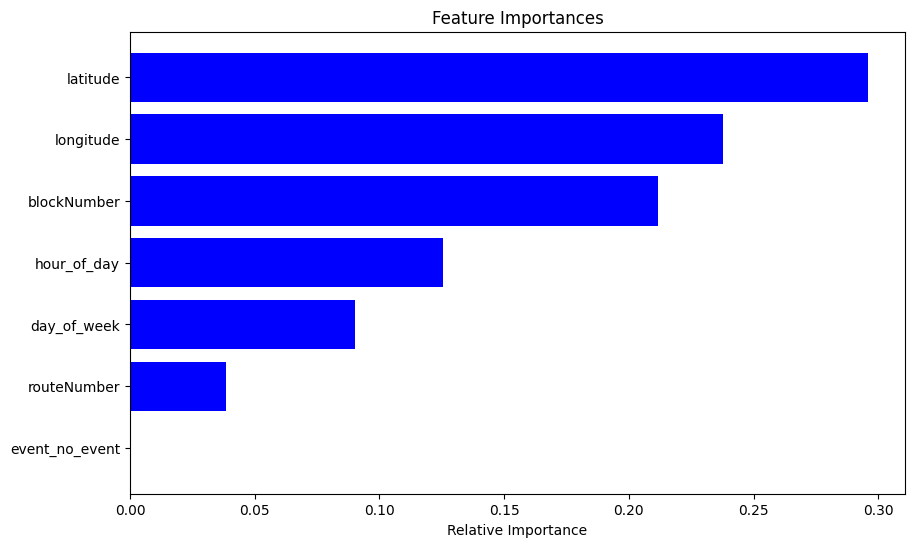

In [109]:
# Feature Importance Visualization
feature_importances = rf_model.feature_importances_
features = X_train.columns
indices = np.argsort(feature_importances)

plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), feature_importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()